# Predicting Customer Dissatisfaction (Olist)

**Business problem**: predict whether a customer will be dissatisfied (`review_score <= 3`) or satisfied (`review_score >= 4`), from order and delivery characteristics available before the review is left.

**Why this problem**: stage 7 (business analyses, query 02) found that late orders average a 2.57/5 review score versus 4.29/5 for on-time orders, and that 65.4% of late orders receive a dissatisfied score versus 17.2% for on-time orders. This notebook tests whether delivery timing dominates the prediction, or whether other order characteristics matter as much.

**Data source**: `ml.dissatisfaction_features` (see `sql/ml/08_dissatisfaction_features_view.sql`), which documents the data leakage safeguards applied when building the feature set.

**Modeling approach**:
- Logistic Regression (`class_weight='balanced'`) as an interpretable baseline.
- Gradient Boosting as a stronger non-linear model, with class imbalance handled via `sample_weight` (scikit-learn's `GradientBoostingClassifier` has no `class_weight` parameter).
- Evaluation: ROC-AUC, precision/recall, confusion matrix.
- Feature importance for both models, to check whether delivery delay dominates the prediction.

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import psycopg2

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

## 2. Load data

Edit the connection string below with your local PostgreSQL credentials. The view already applies every filter and leakage safeguard, so this is a plain `SELECT *`.

In [3]:
# Edit with your local credentials
with psycopg2.connect(
    host="localhost",
    port=5432,
    dbname="olist",
    user="eng",
    password="eng"
) as conn:
    df = pd.read_sql(
        "SELECT * FROM ml.dissatisfaction_features;",
        conn
    )

print(df.shape)
df.head()

/tmp/ipykernel_9460/1318098396.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


(95823, 20)


,order_id,is_dissatisfied,nb_items,nb_distinct_sellers,nb_distinct_products,total_price,total_freight,freight_ratio,avg_product_weight_g,primary_category,payment_type,max_installments,total_payment_value,estimated_delivery_days,actual_delivery_days,delivery_delay_days,is_late,purchase_weekday,purchase_month,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,0,1,1,1,58.90,13.29,0.2256,650.0,cool_stuff,credit_card,2,72.19,16,7,-9,0,3,9,RJ
1,00018f77f2f0320c557190d7a144bdd3,0,1,1,1,239.90,19.93,0.0831,30000.0,pet_shop,credit_card,3,259.83,19,16,-3,0,3,4,SP
2,000229ec398224ef6ca0657da4fc703e,0,1,1,1,199.00,17.87,0.0898,3050.0,furniture_decor,credit_card,5,216.87,22,8,-14,0,0,1,MG
3,00024acbcdf0a6daa1e931b038114c75,0,1,1,1,12.99,12.79,0.9846,200.0,perfumery,credit_card,2,25.78,12,6,-6,0,3,8,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,0,1,1,1,199.90,18.14,0.0907,3750.0,garden_tools,credit_card,3,218.04,41,25,-16,0,6,2,SP


## 3. Quick sanity checks

In [4]:
# Class balance: confirms the class_weight / sample_weight strategy below is needed.
print(df['is_dissatisfied'].value_counts(normalize=True).round(3))

# Missing values: avg_product_weight_g can be NULL for the small number of
# products with no recorded weight (stage 4, section 3.3) — handled by the
# imputer in the preprocessing pipeline below, not dropped here.
df.isnull().sum()[df.isnull().sum() > 0]

is_dissatisfied
0    0.789
1    0.211
Name: proportion, dtype: float64


avg_product_weight_g    16
dtype: int64

## 4. Feature selection

`delivery_delay_days` is dropped here even though it is not a leakage risk: it is an exact linear combination of `actual_delivery_days` and `estimated_delivery_days` (`delivery_delay_days = actual_delivery_days - estimated_delivery_days`). Keeping all three would only split their importance score across redundant features and blur the "does delay dominate?" answer. `is_late` (the sign of that same delay) is kept, since it is the direct, interpretable version of the stage 7 finding.

In [5]:
numeric_features = [
    'nb_items', 'nb_distinct_sellers', 'nb_distinct_products',
    'total_price', 'total_freight', 'freight_ratio', 'avg_product_weight_g',
    'max_installments', 'total_payment_value',
    'estimated_delivery_days', 'actual_delivery_days', 'is_late',
    'purchase_weekday', 'purchase_month',
]
categorical_features = ['primary_category', 'payment_type', 'customer_state']

X = df[numeric_features + categorical_features]
y = df['is_dissatisfied']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 76658 rows | Test: 19165 rows


## 5. Preprocessing

A single `ColumnTransformer` is reused by both models: numeric features are imputed (median) and scaled, categorical features are imputed (most frequent) and one-hot encoded (`handle_unknown='ignore'` so a category unseen in training does not crash the test set).

In [6]:
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

## 6. Baseline: Logistic Regression

`class_weight='balanced'` reweights the loss inversely to class frequency, so the model does not simply predict "satisfied" for every order to minimize error on an imbalanced target.

In [7]:
logreg_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    )),
])

logreg_pipeline.fit(X_train, y_train)

logreg_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
logreg_pred = logreg_pipeline.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, logreg_proba), 4))
print(classification_report(y_test, logreg_pred, target_names=['satisfied', 'dissatisfied'], zero_division=0))

ROC-AUC: 0.7013
              precision    recall  f1-score   support

   satisfied       0.86      0.82      0.84     15128
dissatisfied       0.41      0.49      0.45      4037

    accuracy                           0.75     19165
   macro avg       0.64      0.65      0.64     19165
weighted avg       0.76      0.75      0.75     19165



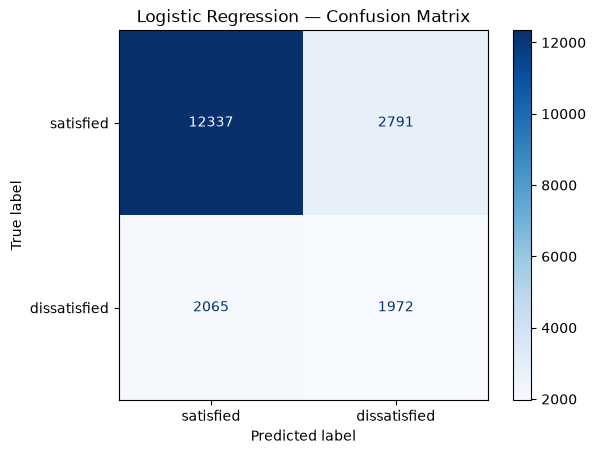

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test, logreg_pred, display_labels=['satisfied', 'dissatisfied'], cmap='Blues'
)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

## 7. Gradient Boosting

`GradientBoostingClassifier` has no `class_weight` parameter, so imbalance is handled by passing `sample_weight` computed with `compute_sample_weight('balanced', y_train)` directly to `.fit()`.

In [9]:
gb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

sample_weights = compute_sample_weight('balanced', y_train)
gb_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)

gb_proba = gb_pipeline.predict_proba(X_test)[:, 1]
gb_pred = gb_pipeline.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, gb_proba), 4))
print(classification_report(y_test, gb_pred, target_names=['satisfied', 'dissatisfied'], zero_division=0))

ROC-AUC: 0.7054
              precision    recall  f1-score   support

   satisfied       0.86      0.82      0.84     15128
dissatisfied       0.42      0.49      0.46      4037

    accuracy                           0.75     19165
   macro avg       0.64      0.66      0.65     19165
weighted avg       0.77      0.75      0.76     19165



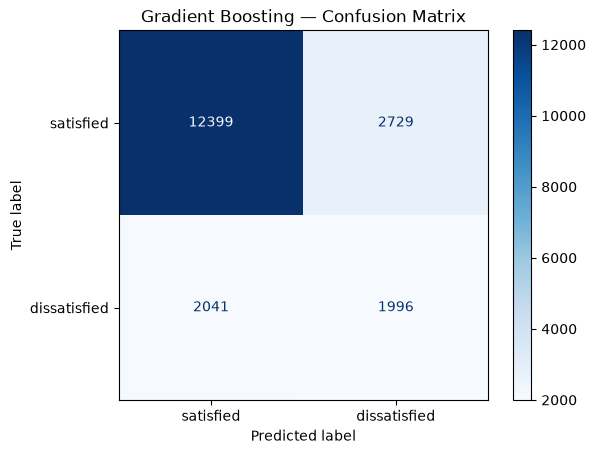

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test, gb_pred, display_labels=['satisfied', 'dissatisfied'], cmap='Blues'
)
plt.title('Gradient Boosting — Confusion Matrix')
plt.show()

## 8. ROC curve comparison

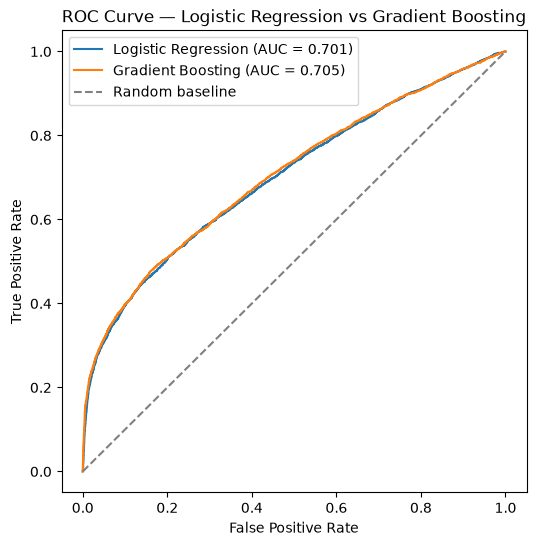

In [11]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, logreg_proba):.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, gb_proba):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression vs Gradient Boosting')
plt.legend()
plt.show()

## 9. Feature importance

The central question: **does delivery delay dominate the prediction**, as the stage 7 business analysis suggested?

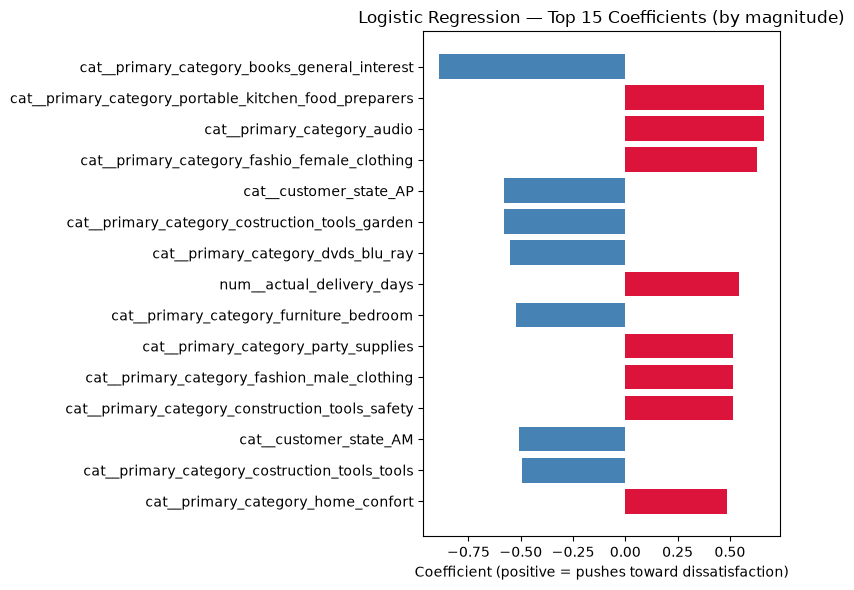

In [12]:
feature_names = logreg_pipeline.named_steps['preprocess'].get_feature_names_out()
logreg_coefs = logreg_pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': logreg_coefs})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
top_coefs = coef_df.sort_values('abs_coefficient', ascending=False).head(15)

plt.figure(figsize=(8, 6))
colors = ['crimson' if c > 0 else 'steelblue' for c in top_coefs['coefficient']]
plt.barh(top_coefs['feature'], top_coefs['coefficient'], color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Coefficient (positive = pushes toward dissatisfaction)')
plt.title('Logistic Regression — Top 15 Coefficients (by magnitude)')
plt.tight_layout()
plt.show()

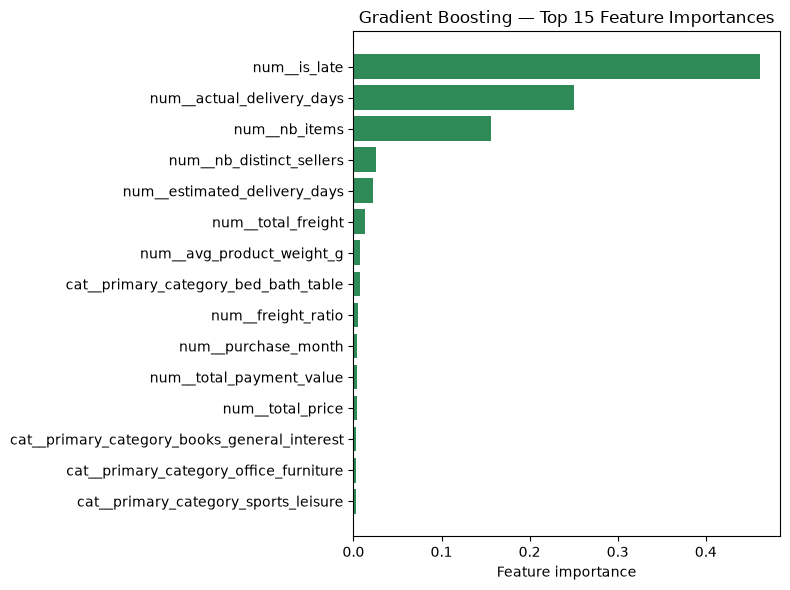

In [13]:
gb_importances = gb_pipeline.named_steps['classifier'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': gb_importances})
top_importances = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_importances['feature'], top_importances['importance'], color='seagreen')
plt.gca().invert_yaxis()
plt.xlabel('Feature importance')
plt.title('Gradient Boosting — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

## 10. Conclusion

- **ROC-AUC**: Logistic Regression = **0.7013** / Gradient Boosting = **0.7054**. The two models perform almost identically (+0.004 for the more complex one), which is itself a finding: the relationship between the available features and dissatisfaction is largely simple and monotonic, so a linear baseline captures nearly all the available signal. The added complexity of Gradient Boosting is not really justified here.
- **Does delivery delay dominate?** Yes, according to Gradient Boosting: `is_late` (importance > 0.4) and `actual_delivery_days` (~0.25) together account for more than 65% of total feature importance, far ahead of everything else. This directly confirms the stage 7 (query 02) finding at the model level, not just as a descriptive statistic.
- **Logistic Regression tells a partly different, less reliable story for "what dominates"**: its top coefficients by magnitude are mostly rare product categories (e.g. `dvds_blu_ray`) and low-volume states (`AP`, `AM`), not delivery delay. This is a known statistical artifact of one-hot-encoded categories with very few observations — the same caveat already applied to sellers with too few orders in stage 7 (query 09): a coefficient fit on a handful of rows can become large and unstable without the variable being genuinely more informative. `actual_delivery_days` does appear in the top 15 with a **positive** coefficient (longer delivery time increases the odds of dissatisfaction), confirming the correct direction, just diluted by noisier features.
- **Business takeaway**: delivery delay is the strongest and most trustworthy lever on customer satisfaction identified in this project. Combined with the stage 7 finding that late-delivery rates are highest in North/Northeastern states (Alagoas 23.9%, Maranhão 19.7%), the clearest actionable recommendation is to prioritize logistics improvements (carrier SLAs, regional fulfillment) in those states, where the impact on review scores is likely to be largest.
- **Model limitation, stated plainly**: recall on the dissatisfied class is modest (49% for both models) — the model catches roughly one dissatisfied customer in two. With an AUC around 0.70 and only order/delivery-level features (no text, no customer history), this is an honest, credible baseline for a project centered on SQL rather than a production-ready churn/satisfaction classifier.